In [89]:
#Compute Drawdowns

C:\Users\delni\AppData\Local\Temp\ipykernel_31216\4166903058.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  me_m = pd.read_csv('Portfolios_Formed_on_ME_monthly_EW.csv', header = 0, index_col = 0, parse_dates = True, na_values = -99.99)


<Axes: >

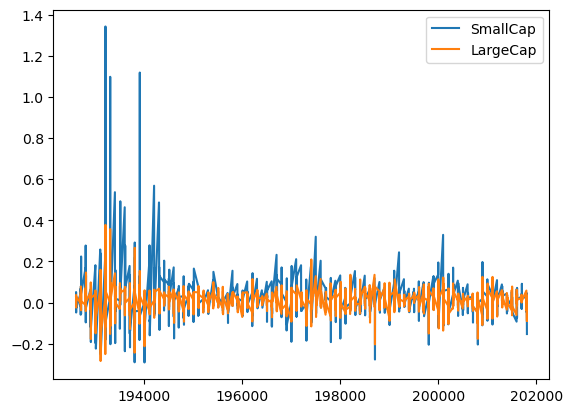

In [90]:
import pandas as pd
me_m = pd.read_csv('Portfolios_Formed_on_ME_monthly_EW.csv', header = 0, index_col = 0, parse_dates = True, na_values = -99.99)

rets = me_m[['Lo 10', 'Hi 10']]
rets.columns = ['SmallCap', 'LargeCap']
rets = rets/100
rets.plot.line()

In [91]:
rets.head()

,SmallCap,LargeCap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


In [92]:
rets.index

Index([192607, 192608, 192609, 192610, 192611, 192612, 192701, 192702, 192703,
       192704,
       ...
       201803, 201804, 201805, 201806, 201807, 201808, 201809, 201810, 201811,
       201812],
      dtype='int64', length=1110)

In [93]:
rets.index = pd.to_datetime(rets.index, format='%Y%m')

In [94]:
rets.index = rets.index.to_period('M')
rets.head()

,SmallCap,LargeCap
1926-07,-0.0145,0.0329
1926-08,0.0512,0.0370
1926-09,0.0093,0.0067
1926-10,-0.0484,-0.0243
1926-11,-0.0078,0.0270


In [95]:
rets.loc['1975']

,SmallCap,LargeCap
1975-01,0.3202,0.1286
1975-02,0.0657,0.0613
1975-03,0.0989,0.0414
1975-04,0.0288,0.0531
1975-05,0.0811,0.0610
1975-06,0.0779,0.0524
1975-07,0.0218,-0.0703
1975-08,-0.0525,-0.0177
1975-09,-0.0351,-0.0468
1975-10,-0.0009,0.0620


**Compute Drawdowns**

In [96]:
wealth_index = 1000*(1+rets['LargeCap']).cumprod()

In [97]:
wealth_index.head()

1926-07    1032.900000
1926-08    1071.117300
1926-09    1078.293786
1926-10    1052.091247
1926-11    1080.497711
Freq: M, Name: LargeCap, dtype: float64

<Axes: >

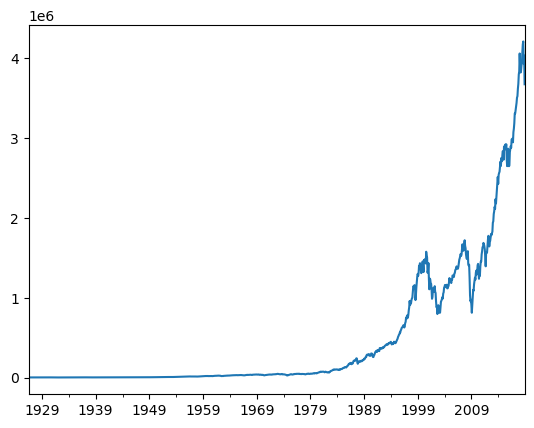

In [98]:
wealth_index.plot.line()

In [99]:
previous_peaks = wealth_index.cummax()

<Axes: >

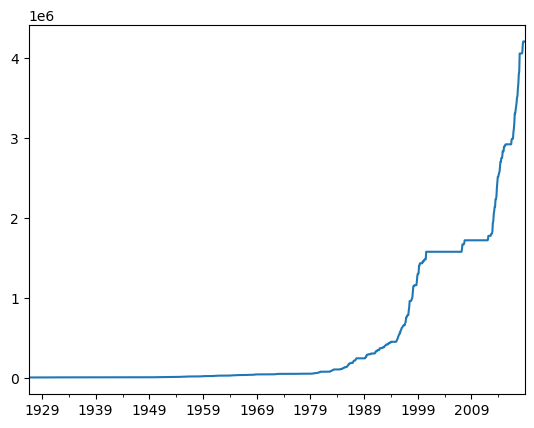

In [100]:
previous_peaks.plot()

<Axes: >

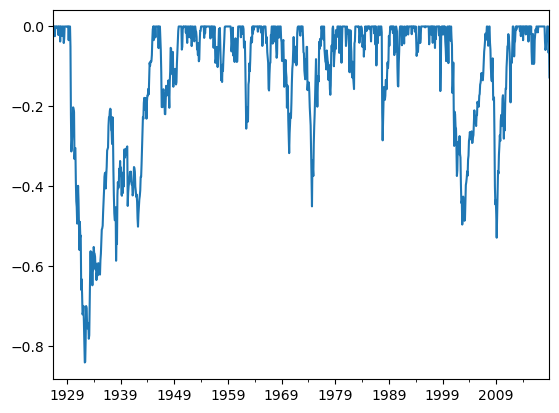

In [101]:
drawdown = (wealth_index - previous_peaks)/previous_peaks
drawdown.plot()

In [102]:
drawdown.head()

1926-07    0.0000
1926-08    0.0000
1926-09    0.0000
1926-10   -0.0243
1926-11    0.0000
Freq: M, Name: LargeCap, dtype: float64

In [103]:
drawdown.min()

-0.8400375277943123

In [104]:
drawdown.loc['1975':].idxmin()

Period('2009-02', 'M')

In [105]:
drawdown.idxmin()

Period('1932-05', 'M')

In [106]:
rets.index

PeriodIndex(['1926-07', '1926-08', '1926-09', '1926-10', '1926-11', '1926-12',
             '1927-01', '1927-02', '1927-03', '1927-04',
             ...
             '2018-03', '2018-04', '2018-05', '2018-06', '2018-07', '2018-08',
             '2018-09', '2018-10', '2018-11', '2018-12'],
            dtype='period[M]', length=1110)

In [114]:
def drawdown(return_series: pd.Series): 
    """
    Takes a time series of asset returns
    Computes and returns a DataFrame that contains:
    the wealth index
    the previous peaks
    percent drawdowns
    """
    wealth_index = 1000*(1+return_series).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks)/previous_peaks
    return pd.DataFrame({
        'Wealth': wealth_index,
        'Peaks': previous_peaks,
        'Drawdowns': drawdowns
    })

In [115]:
drawdown(rets['LargeCap']).head()

,Wealth,Peaks,Drawdowns
1926-07-01,1032.900000,1032.900000,0.0000
1926-08-01,1071.117300,1071.117300,0.0000
1926-09-01,1078.293786,1078.293786,0.0000
1926-10-01,1052.091247,1078.293786,-0.0243
1926-11-01,1080.497711,1080.497711,0.0000


In [116]:
drawdown(rets['LargeCap'])[['Wealth', 'Peaks']].head()

,Wealth,Peaks
1926-07-01,1032.900000,1032.900000
1926-08-01,1071.117300,1071.117300
1926-09-01,1078.293786,1078.293786
1926-10-01,1052.091247,1078.293786
1926-11-01,1080.497711,1080.497711


<Axes: >

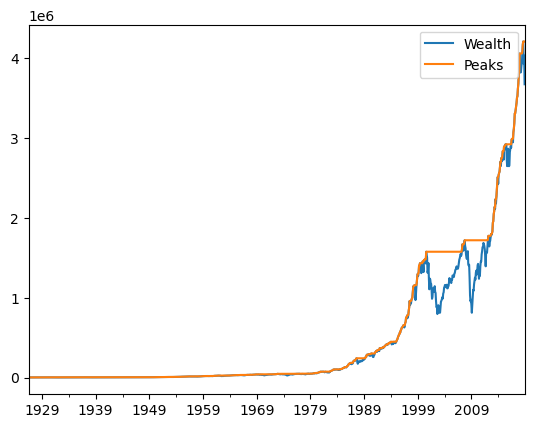

In [117]:
drawdown(rets['LargeCap'])[['Wealth', 'Peaks']].plot()

<Axes: >

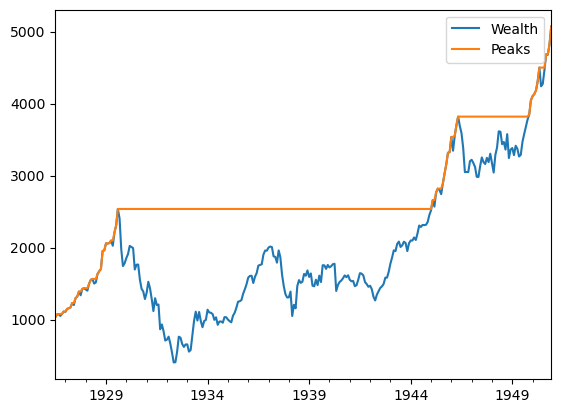

In [118]:
drawdown(rets[:'1950']['LargeCap'])[['Wealth', 'Peaks']].plot()

In [122]:
drawdown(rets['LargeCap'])['Drawdowns'].min()

-0.8400375277943123

In [127]:
drawdown(rets['1950':]['SmallCap'])['Drawdowns'].idxmin()

Period('1974-12', 'M')

In [128]:
drawdown(rets['1975':]['SmallCap'])['Drawdowns'].min()

-0.6312068077252386

In [129]:
drawdown(rets['1975':]['LargeCap'])['Drawdowns'].min()

-0.5280945042309303

In [130]:
drawdown(rets['1975':]['LargeCap'])['Drawdowns'].idxmin()

Period('2009-02', 'M')